# 🦋 Parvaneh: independent synthetic examples

This notebook exercises the public package without external executables, book data, or downloaded files. Every array is generated deterministically in memory.

In [1]:
from pathlib import Path
import sys, time
import matplotlib.pyplot as plt
import numpy as np

ROOT = Path.cwd().resolve().parent if Path.cwd().name == 'notebooks' else Path.cwd().resolve()
SRC = ROOT / 'src'
if (SRC / 'parvaneh').is_dir() and str(SRC) not in sys.path:
    sys.path.insert(0, str(SRC))

from parvaneh import (
    SAKURA, SAKURA_DIVERGING, flynn_unwrap, goldstein_unwrap,
    make_synthetic, phase_residues, quality_guided_unwrap,
    rmse_aligned, unwrap, unwrap_lp,
)

## 1. Generate an original wrapped-phase experiment

The generator combines a phase ramp and localized smooth structures, adds spatially varying Gaussian noise, wraps the observation into $[-\pi,\pi)$, and returns a reliability map.

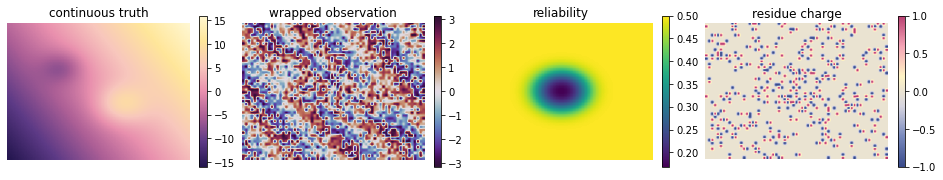

In [2]:
truth, wrapped, quality = make_synthetic((48, 64), noise=1.20, seed=19)
residues = phase_residues(wrapped)

fig, axes = plt.subplots(1, 4, figsize=(13, 3), constrained_layout=True)
items = [(truth, 'continuous truth', SAKURA),
         (wrapped, 'wrapped observation', 'twilight_shifted'),
         (quality, 'reliability', 'viridis'),
         (residues, 'residue charge', SAKURA_DIVERGING)]
for axis, (image, title, cmap) in zip(axes, items):
    artist = axis.imshow(image, origin='lower', cmap=cmap)
    axis.set_title(title); axis.axis('off')
    fig.colorbar(artist, ax=axis, shrink=.72)
plt.show()

## 2. Run independent algorithm families

The comparison uses identical input and offset-aligned RMSE. Numba compilation is warmed before timing.

In [3]:
quality_guided_unwrap(wrapped[:16, :20], 'min_gradient', backend='numba')
methods = {
    'Goldstein': lambda: goldstein_unwrap(wrapped),
    'quality guided': lambda: quality_guided_unwrap(wrapped, 'min_gradient', backend='numba'),
    'weighted L2': lambda: unwrap(wrapped, quality, backend='numba', workers=-1),
    'robust L1.2': lambda: unwrap_lp(wrapped, p=1.2, outer_iter=6),
    'Flynn': lambda: flynn_unwrap(wrapped),
}
results, metrics = {}, []
for name, solve in methods.items():
    start = time.perf_counter(); result = solve(); elapsed = time.perf_counter() - start
    result = result + np.mean(truth - result)
    results[name] = result
    metrics.append((name, rmse_aligned(result, truth), elapsed))

for name, error, elapsed in metrics:
    print(f'{name:16s} RMSE={error:.5f} rad  time={elapsed:.4f} s')

Goldstein        RMSE=7.17996 rad  time=0.0886 s
quality guided   RMSE=3.62069 rad  time=0.0006 s
weighted L2      RMSE=4.16225 rad  time=0.0144 s
robust L1.2      RMSE=1.88633 rad  time=0.1288 s
Flynn            RMSE=1.50381 rad  time=0.4189 s


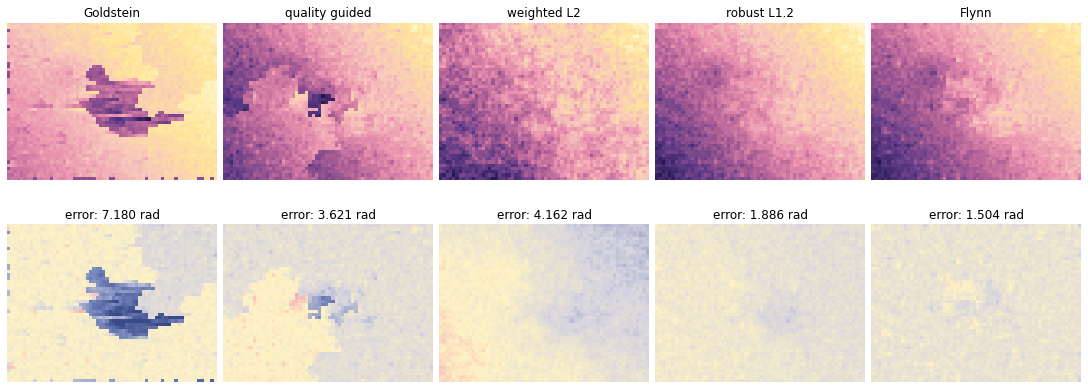

In [4]:
fig, axes = plt.subplots(2, len(results), figsize=(15, 5.6), constrained_layout=True)
limit = max(np.percentile(np.abs(value - truth), 99) for value in results.values())
for column, (name, result) in enumerate(results.items()):
    axes[0, column].imshow(result, origin='lower', cmap=SAKURA)
    axes[0, column].set_title(name)
    axes[1, column].imshow(result - truth, origin='lower', cmap=SAKURA_DIVERGING, vmin=-limit, vmax=limit)
    axes[1, column].set_title(f'error: {rmse_aligned(result, truth):.3f} rad')
    axes[0, column].axis('off'); axes[1, column].axis('off')
axes[0, 0].set_ylabel('reconstruction'); axes[1, 0].set_ylabel('error')
plt.show()

## 3. Reproducibility checks

A valid public example should be deterministic, finite, shape preserving, and phase-congruent where required. The package test suite adds backend-equivalence, topology, input-validation, and raw-I/O tests.

```bash
pytest -q
python benchmarks/benchmark_backends.py
python benchmarks/benchmark_path_following.py
```